# TP 2.3 – Classification de tweets : catastrophe réelle ou non ?

**Groupe :** Nom 1, Nom 2, Nom 3 – ING 4 Data & IA

## Introduction

### Contexte et cas d'usage
Pendant une catastrophe naturelle ou un accident (incendie, séisme, inondation, explosion...), les réseaux sociaux comme Twitter sont souvent la première source d'information. Des témoins publient sur place avant l'arrivée des médias ou des secours. Les services d'urgence, les ONG ou les agences de presse ont donc intérêt à repérer automatiquement les tweets qui annoncent une vraie catastrophe.

La difficulté est que le vocabulaire des catastrophes est aussi très utilisé au sens figuré. Par exemple, "the sky was ablaze last night" décrit un coucher de soleil, alors que "forest fire near La Ronge" décrit un vrai incendie. Un simple filtre par mots-clés ne suffit donc pas, et c'est là que le NLP devient utile.

Notre objectif est de construire un modèle de classification binaire qui prédit, à partir du texte d'un tweet, s'il parle d'une catastrophe réelle (1) ou non (0).

### Jeu de données
Nous utilisons le dataset Kaggle **"NLP with Disaster Tweets – cleaning data"** (auteur : vbmokin). C'est une version corrigée des données de la compétition Kaggle "Real or Not? NLP with Disaster Tweets". Les tweets ont été annotés manuellement.

Colonnes du fichier d'entraînement :
- `id` : identifiant du tweet
- `keyword` : mot-clé lié à une catastrophe présent dans le tweet (peut être vide)
- `location` : lieu déclaré par l'utilisateur (peut être vide)
- `text` : contenu du tweet
- `target` : 1 si le tweet parle d'une vraie catastrophe, 0 sinon

Le fichier de test du dataset n'a pas d'étiquettes (c'était le test de la compétition). Nous travaillons donc uniquement avec le fichier d'entraînement, que nous découpons nous-mêmes en train et test pour pouvoir évaluer nos modèles.

### Démarche
1. Chargement et exploration des données
2. Nettoyage et préparation du texte
3. Modèle 1 : TF-IDF + Naive Bayes multinomial
4. Modèle 2 (bonus) : réseau de neurones convolutif (CNN) avec embeddings
5. Évaluation et comparaison des deux modèles

## 1. Installation et import des librairies

On installe les librairies avec `%pip` : sous VS Code, cette commande installe les paquets dans l'environnement du kernel sélectionné. Après la première installation, il faut redémarrer le kernel.

In [1]:
%pip install -q kagglehub pandas numpy matplotlib seaborn nltk scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# NLTK : tokenisation, stopwords et lemmatisation
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# scikit-learn : vectorisation, modèle ML et métriques
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Keras : modèle de deep learning
import keras
from keras import layers

# On fixe la graine aléatoire pour avoir les mêmes résultats à chaque exécution
SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

sns.set_theme(style='whitegrid')

## 2. Chargement du jeu de données

On récupère le dataset directement avec l'API Kaggle via la librairie `kagglehub`. Pour un dataset public, aucune clé n'est normalement nécessaire. Si Kaggle en demande une, il faut générer un token dans Kaggle > Settings > API et placer le fichier `kaggle.json` dans le dossier `.kaggle` de son répertoire utilisateur.

On enregistre aussi une copie du fichier dans le dossier `data/` du projet, car le jeu de données fait partie des livrables.

In [3]:
import kagglehub

# Téléchargement du dataset (mis en cache après le premier appel)
path = kagglehub.dataset_download("vbmokin/nlp-with-disaster-tweets-cleaning-data")
fichiers = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
print('Fichiers du dataset :', [os.path.basename(f) for f in fichiers])

# On garde le fichier d'entraînement, le seul qui contient la colonne target
fichier_train = [f for f in fichiers if 'train' in os.path.basename(f).lower()][0]
df = pd.read_csv(fichier_train)

# Copie locale du dataset pour le livrable
os.makedirs('data', exist_ok=True)
df.to_csv('data/disaster_tweets_train.csv', index=False)

print('Dimensions :', df.shape)
df.head()

c:\Users\chloe\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.00M/1.00M [00:00<00:00, 1.80MB/s]

Extracting files...
Fichiers du dataset : ['test_data_cleaning.csv', 'test_data_cleaning2.csv', 'train_data_cleaning.csv', 'train_data_cleaning2.csv']
Dimensions : (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this # earthquake...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask . Canada,1
2,5,NaN,NaN,All residents asked to ' shelter in place ' ...,1
3,6,NaN,NaN,"13,000 people receive # wildfires evacuation ...",1
4,7,NaN,NaN,Just got sent this photo from Ruby # Alaska a...,1


## 3. Exploration des données

Avant de nettoyer, on étudie la structure des données : types de colonnes, valeurs manquantes, doublons, équilibre des classes, longueur des tweets et vocabulaire. Ces observations guident les choix de nettoyage et de modélisation.

### 3.1 Informations générales et valeurs manquantes

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [5]:
# Nombre et pourcentage de valeurs manquantes par colonne
manquants = pd.DataFrame({
    'nb_manquants': df.isna().sum(),
    'pourcentage': (df.isna().mean() * 100).round(2)
})
manquants

,nb_manquants,pourcentage
id,0,0.00
keyword,61,0.80
location,2533,33.27
text,0,0.00
target,0,0.00


Les colonnes `text` et `target` sont complètes, ce qui est le plus important. `location` a beaucoup de valeurs manquantes (environ un tiers des lignes). Elle est aussi saisie librement par l'utilisateur ("Earth", "somewhere", "NYC", "New York"...), donc peu fiable : nous ne l'utiliserons pas. `keyword` est presque toujours renseignée, mais c'est un mot déjà présent dans le texte. Nous l'utilisons pour l'exploration, pas comme variable du modèle.

### 3.2 Répartition des classes

target
0    4342
1    3271
Name: count, dtype: int64

Proportions (%) :
target
0    57.0
1    43.0
Name: proportion, dtype: float64


C:\Users\chloe\AppData\Local\Temp\ipykernel_21600\2892898474.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=['steelblue', 'darkorange'])


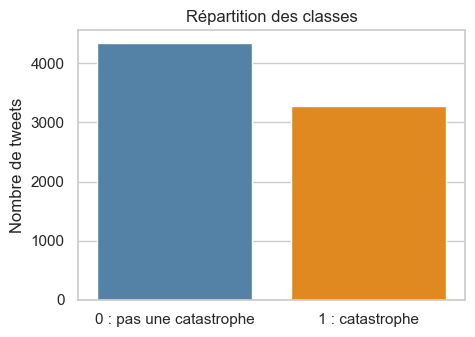

In [6]:
repartition = df['target'].value_counts().sort_index()
print(repartition)
print('\nProportions (%) :')
print((df['target'].value_counts(normalize=True).sort_index() * 100).round(1))

plt.figure(figsize=(5, 3.5))
sns.countplot(x='target', data=df, palette=['steelblue', 'darkorange'])
plt.xticks([0, 1], ['0 : pas une catastrophe', '1 : catastrophe'])
plt.title('Répartition des classes')
plt.xlabel('')
plt.ylabel('Nombre de tweets')
plt.show()

Les classes sont légèrement déséquilibrées : environ 57 % de tweets "normaux" contre 43 % de tweets de catastrophe. Le déséquilibre n'est pas assez fort pour imposer un rééquilibrage (sur-échantillonnage, etc.), mais il faut en tenir compte :
- un modèle qui prédirait toujours 0 aurait déjà environ 57 % d'accuracy, donc l'accuracy seule ne suffit pas pour évaluer. Nous regarderons aussi la précision, le rappel et le F1-score ;
- le découpage train/test devra être stratifié pour garder les mêmes proportions dans les deux jeux.

### 3.3 Doublons

In [7]:
# Tweets dont le texte apparaît plusieurs fois
nb_doublons = df.duplicated(subset='text').sum()
print('Nombre de doublons sur le texte :', nb_doublons)

# Parmi eux, textes identiques mais avec des étiquettes différentes
labels_par_texte = df.groupby('text')['target'].nunique()
textes_contradictoires = labels_par_texte[labels_par_texte > 1].index
print('Textes avec des étiquettes contradictoires :', len(textes_contradictoires))

df[df['text'].duplicated(keep=False)].sort_values('text')[['text', 'target']].head(10)

Nombre de doublons sur le texte : 632
Textes avec des étiquettes contradictoires : 66


,text,target
7141,# shoes Asics GT - II Super Red 2 . 0 11 Ron...,0
7134,# shoes Asics GT - II Super Red 2 . 0 11 Ron...,0
4834,@ Royal Carribean do your passengers know ab...,1
4827,@ Royal Carribean do your passengers know ab...,1
5785,Cindy Noonan @ Cindy Noonan - Heartbreak in ...,1
5807,Cindy Noonan @ Cindy Noonan - Heartbreak in ...,0
2168,# ? # ? # ? # ? Malaysia Airlines ...,1
2165,# ? # ? # ? # ? Malaysia Airlines ...,1
2170,# ? # ? # ? # ? Malaysia Airlines ...,1
2175,# ? # ? # ? # ? Malaysia Airlines ...,1


Le dataset contient des tweets en double, souvent des retweets ou des messages automatiques. C'est un problème pour l'évaluation : si un même tweet se retrouve à la fois dans le train et dans le test, le modèle le "reconnaît" au lieu de généraliser, et le score est surestimé. Certains doublons ont en plus des étiquettes contradictoires, ce qui ne peut qu'embrouiller le modèle. Nous les traiterons à l'étape de nettoyage.

### 3.4 Longueur des tweets

        nb_caracteres  nb_mots
target                        
0                89.3     17.1
1                96.7     17.6


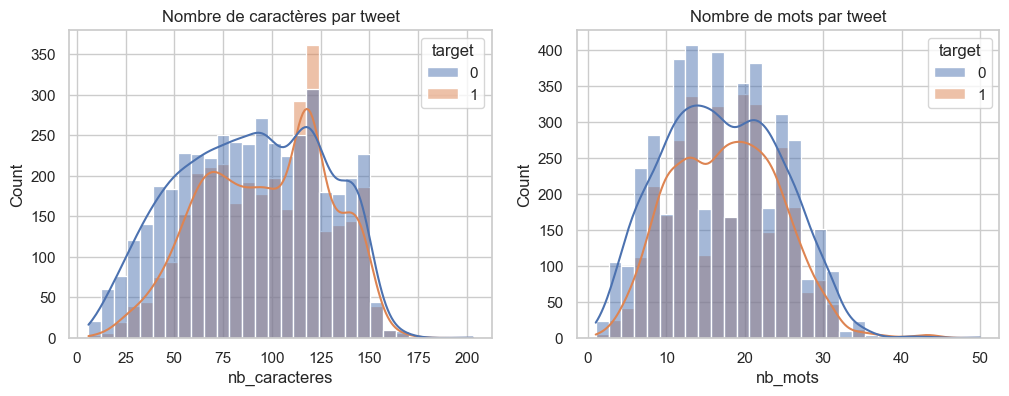

In [8]:
df['nb_caracteres'] = df['text'].str.len()
df['nb_mots'] = df['text'].str.split().str.len()

print(df.groupby('target')[['nb_caracteres', 'nb_mots']].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=df, x='nb_caracteres', hue='target', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Nombre de caractères par tweet')
sns.histplot(data=df, x='nb_mots', hue='target', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Nombre de mots par tweet')
plt.show()

Les tweets sont courts : une quinzaine de mots en moyenne, à cause de la limite de caractères de Twitter. Les tweets de catastrophe sont en moyenne un peu plus longs, car ils décrivent souvent un événement de manière factuelle (lieu, bilan, source). La différence reste faible, donc la longueur seule ne permet pas de classer : c'est bien le contenu du texte qu'il faut analyser.

La petite taille des textes a aussi une conséquence pour la suite : chaque tweet ne contient que peu de mots, donc la représentation vectorielle sera très creuse.

### 3.5 Mots-clés les plus fréquents par classe

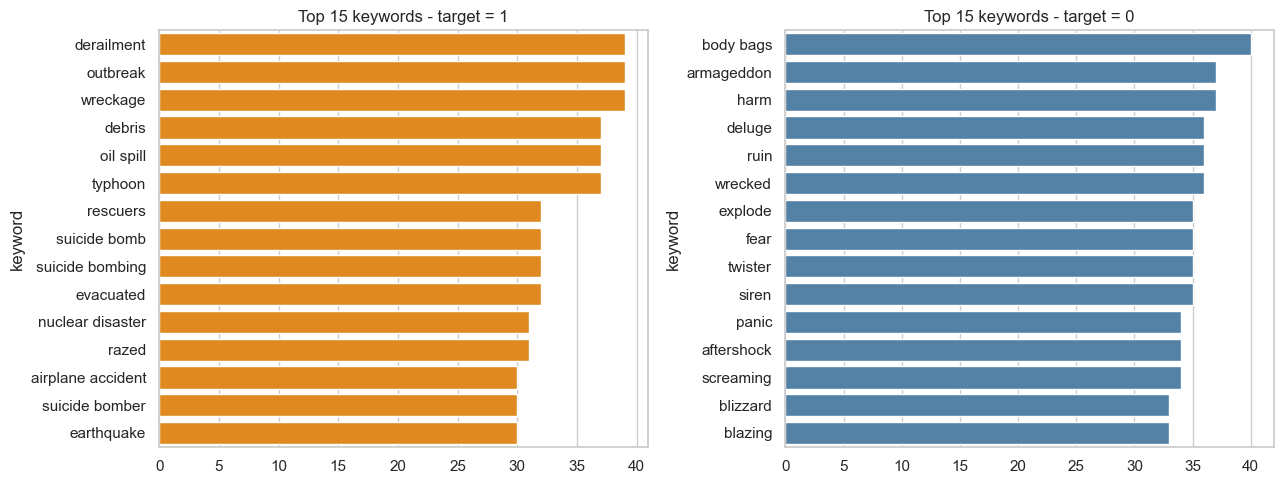

In [9]:
# Certains mots-clés contiennent '%20' à la place des espaces (encodage URL)
df['keyword'] = df['keyword'].fillna('').str.replace('%20', ' ')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (cible, couleur) in enumerate([(1, 'darkorange'), (0, 'steelblue')]):
    top_kw = df[(df['target'] == cible) & (df['keyword'] != '')]['keyword'].value_counts().head(15)
    sns.barplot(x=top_kw.values, y=top_kw.index, color=couleur, ax=axes[i])
    axes[i].set_title(f'Top 15 keywords - target = {cible}')
plt.tight_layout()
plt.show()

Les mots-clés des tweets de catastrophe sont très concrets : accidents, feux de forêt, attentats, bilans humains... Du côté des tweets normaux, on retrouve aussi du vocabulaire de catastrophe ("body bags", "ruin", "screaming", "wrecked"), mais employé au sens figuré ou dans un contexte banal. Cela confirme la difficulté du problème : le même champ lexical apparaît dans les deux classes, et le modèle devra s'appuyer sur l'ensemble des mots du tweet, pas sur un seul mot-clé.

### 3.6 Éléments spécifiques à Twitter

In [10]:
# On compte les éléments typiques des tweets qui peuvent être du bruit pour le modèle
elements = {
    'URLs': r'http\S+|www\.\S+',
    'Mentions @': r'@\w+',
    'Hashtags #': r'#\w+',
    'Chiffres': r'\d',
    'Entités HTML (&amp; ...)': r'&\w+;',
}
for nom, motif in elements.items():
    part = df['text'].str.contains(motif, regex=True).mean() * 100
    print(f'{nom:28s}: présent dans {part:5.1f} % des tweets')

URLs                        : présent dans   0.0 % des tweets
Mentions @                  : présent dans   0.0 % des tweets
Hashtags #                  : présent dans   0.0 % des tweets
Chiffres                    : présent dans  28.6 % des tweets
Entités HTML (&amp; ...)    : présent dans   0.0 % des tweets


L'auteur du dataset a déjà fait un premier nettoyage (suppression des liens, correction de fautes, développement des contractions). Il reste néanmoins des éléments à traiter : ponctuation, chiffres, éventuels hashtags et mentions. Les hashtags sont intéressants car ils contiennent souvent le mot le plus informatif du tweet (#earthquake) : on gardera le mot et on retirera seulement le symbole #.

## 4. Nettoyage et prétraitement du texte

Le texte brut ne peut pas être utilisé directement par un modèle. On applique les étapes classiques vues en cours et dans le TP 2.1, adaptées à des tweets :

1. **Suppression des doublons** et des textes aux étiquettes contradictoires (voir 3.3).
2. **Mise en minuscules** : "Fire" et "fire" doivent être le même mot.
3. **Développement des négations** ("don't" devient "do not"). Dans le TP 2.1, "wasn't" était transformé en "wasn t" par la regex, puis "wasn" était supprimé comme stopword : la négation disparaissait. On évite ce problème en traitant les négations avant la regex.
4. **Suppression du bruit** : URLs, mentions, symbole #, entités HTML, chiffres et ponctuation. On ne garde que les lettres.
5. **Tokenisation** avec `word_tokenize` de NLTK : on découpe chaque tweet en une liste de mots (tokens).
6. **Suppression des stopwords** ("the", "is", "and"...), des mots très fréquents qui n'apportent pas d'information sur la classe. On garde volontairement les négations (not, no, never) qui peuvent changer le sens d'une phrase.
7. **Lemmatisation** : chaque mot est ramené à sa forme de base ("fires" devient "fire", "buildings" devient "building"). Nous avons préféré la lemmatisation au stemming utilisé dans le TP 2.1, car le stemming coupe les mots de façon brute ("disaster" devient "disast"), alors que la lemmatisation garde de vrais mots. Les résultats restent ainsi lisibles lors de l'interprétation.

In [11]:
# 1. Suppression des textes contradictoires puis des doublons
avant = len(df)
df = df[~df['text'].isin(textes_contradictoires)]
df = df.drop_duplicates(subset='text').reset_index(drop=True)
print(f'{avant - len(df)} lignes supprimées, il reste {len(df)} tweets')

698 lignes supprimées, il reste 6915 tweets


In [12]:
# Liste des stopwords anglais, sans les négations qu'on veut conserver
negations = {'no', 'not', 'nor', 'never'}
stop_words = set(stopwords.words('english')) - negations
lemmatizer = WordNetLemmatizer()

def nettoyer_tweet(texte):
    texte = texte.lower()                                 # minuscules
    texte = re.sub(r"won't", 'will not', texte)           # négations irrégulières
    texte = re.sub(r"can't", 'can not', texte)
    texte = re.sub(r"n't\b", ' not', texte)               # don't -> do not
    texte = re.sub(r'http\S+|www\.\S+', ' ', texte)       # liens
    texte = re.sub(r'@\w+', ' ', texte)                   # mentions
    texte = re.sub(r'&\w+;', ' ', texte)                  # entités HTML
    texte = texte.replace('#', ' ')                       # on garde le mot du hashtag
    texte = re.sub(r'[^a-z\s]', ' ', texte)               # uniquement des lettres
    tokens = word_tokenize(texte)                         # tokenisation
    tokens = [lemmatizer.lemmatize(mot) for mot in tokens
              if mot not in stop_words and len(mot) > 1]  # stopwords + lemmatisation
    return ' '.join(tokens)

# Test sur une phrase inventée pour vérifier chaque étape
print(nettoyer_tweet("BREAKING: #Wildfires near @CityOfLA, 3 buildings didn't survive!! http://t.co/abc"))

breaking wildfire near building not survive


Sur l'exemple, le hashtag, la mention, le lien, les chiffres et la ponctuation ont été retirés. "Wildfires" et "buildings" sont passés au singulier, et la négation "didn't" est conservée sous la forme "not". On applique maintenant la fonction à tout le dataset.

In [13]:
df['text_clean'] = df['text'].apply(nettoyer_tweet)

# Comparaison avant / après sur quelques tweets
pd.set_option('display.max_colwidth', 110)
df[['text', 'text_clean', 'target']].sample(8, random_state=SEED)

,text,text_clean,target
5219,@ teamVODG Discovered by @ Nick Cannon \n Listen / Buy @ Mandy Rain # RIOT on @ iTunes Music @ iTu...,teamvodg discovered nick cannon listen buy mandy rain riot itunes music itunes blowmandyup,0
828,Damn bloody hot,damn bloody hot,0
3269,I liked a @ YouTube video Mini Pony packs a punch . Live report from the Salem County Fair on CBS3 Eyew...,liked youtube video mini pony pack punch live report salem county fair cbs eyewitness,0
1433,Fuck Neil go fall off a cliff or something . # yr ?,fuck neil go fall cliff something yr,0
4937,tomorrow ' s going to be a year since I went to the Panic ! concert dressed as afycso ryan do u guys reme...,tomorrow going year since went panic concert dressed afycso ryan guy remember,1
2651,LLF TALK WORLD NEWS U . S . in record hurricane drought - The United States has not been hit by a major...,llf talk world news record hurricane drought united state not hit major hurricane,1
2177,Draw Day Demolition Daily football selection service that consistently makes money lay yo,draw day demolition daily football selection service consistently make money lay yo,0
2333,August 5 1620 one hundred - odd pilgrims from England and Holland set sail for the New World . They were ...,august one hundred odd pilgrim england holland set sail new world unimpressed,0


In [14]:
# Certains tweets peuvent devenir vides après nettoyage (tweet composé uniquement d'un lien par exemple)
vides = (df['text_clean'].str.strip() == '').sum()
print('Tweets vides après nettoyage :', vides)
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)

df['nb_tokens'] = df['text_clean'].str.split().str.len()
print('\nNombre de tokens par tweet après nettoyage :')
print(df['nb_tokens'].describe().round(1))

Tweets vides après nettoyage : 0

Nombre de tokens par tweet après nettoyage :
count    6915.0
mean        9.2
std         3.6
min         1.0
25%         6.5
50%         9.0
75%        12.0
max        23.0
Name: nb_tokens, dtype: float64


Après nettoyage, un tweet contient environ deux fois moins de mots qu'avant : les stopwords représentaient une grande partie du texte. Il reste en moyenne une dizaine de tokens porteurs de sens par tweet.

### 4.1 Vocabulaire après nettoyage

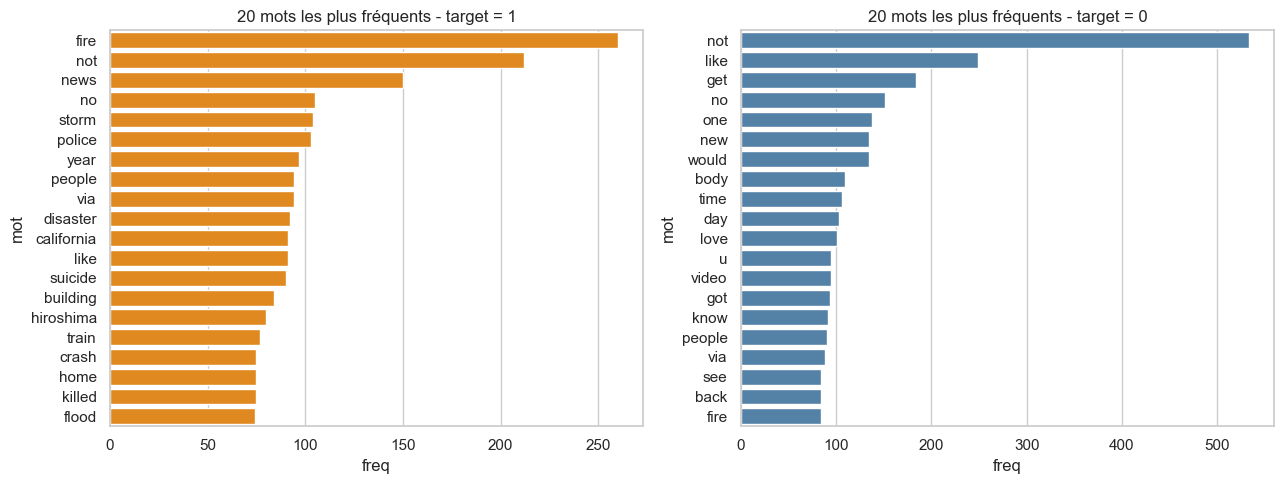

Taille du vocabulaire après nettoyage : 14717 mots distincts


In [15]:
# Mots les plus fréquents dans chaque classe, après nettoyage
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for i, (cible, couleur) in enumerate([(1, 'darkorange'), (0, 'steelblue')]):
    mots = ' '.join(df[df['target'] == cible]['text_clean']).split()
    top = pd.DataFrame(Counter(mots).most_common(20), columns=['mot', 'freq'])
    sns.barplot(x='freq', y='mot', data=top, color=couleur, ax=axes[i])
    axes[i].set_title(f'20 mots les plus fréquents - target = {cible}')
plt.tight_layout()
plt.show()

vocab_total = set(' '.join(df['text_clean']).split())
print('Taille du vocabulaire après nettoyage :', len(vocab_total), 'mots distincts')

Après nettoyage, les deux classes se distinguent nettement. Les tweets de catastrophe contiennent des mots liés aux événements (fire, flood, storm, suicide, bomber...), aux victimes (killed, dead) et au vocabulaire journalistique (news, police, california, disaster). Les tweets normaux contiennent des mots du quotidien et de l'émotion (like, love, new, get, one). Certains mots comme "fire" ou "people" sont fréquents dans les deux classes : ce sont les cas ambigus sur lesquels les modèles risquent de se tromper.

Le vocabulaire compte plus de 10 000 mots distincts, mais une grande partie n'apparaît qu'une seule fois (noms propres, fautes). Ces mots rares seront filtrés lors de la vectorisation.

In [16]:
# Sauvegarde du dataset nettoyé (livrable)
df[['id', 'keyword', 'text', 'text_clean', 'target']].to_csv('data/disaster_tweets_clean.csv', index=False)
print('Dataset nettoyé enregistré dans data/disaster_tweets_clean.csv')

Dataset nettoyé enregistré dans data/disaster_tweets_clean.csv


## 5. Séparation entraînement / test

On découpe les données en 80 % pour l'entraînement et 20 % pour le test, avec `stratify` pour conserver la proportion de chaque classe.

Contrairement aux scripts du TP 2.2, où le TF-IDF était calculé sur tout le corpus avant le découpage, on sépare les données en premier. La vectorisation est ensuite apprise uniquement sur le train. Sinon, le vocabulaire et les poids du TF-IDF seraient influencés par le jeu de test : c'est une fuite de données, qui donne des résultats trop optimistes.

In [17]:
X = df['text_clean']
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)

print('Train :', len(X_train), 'tweets - part de catastrophes :', round(y_train.mean(), 3))
print('Test  :', len(X_test), 'tweets - part de catastrophes :', round(y_test.mean(), 3))

Train : 5532 tweets - part de catastrophes : 0.409
Test  : 1383 tweets - part de catastrophes : 0.409


Les proportions de catastrophes sont les mêmes dans les deux jeux, la stratification a bien fonctionné.

## 6. Modèle 1 : TF-IDF + Naive Bayes multinomial

### 6.1 Vectorisation TF-IDF

Les modèles de machine learning ne travaillent qu'avec des nombres : il faut transformer chaque tweet en vecteur.

Dans le TP 2.1, on utilisait un sac de mots (`CountVectorizer`), qui compte simplement le nombre d'apparitions de chaque mot. Nous utilisons ici le **TF-IDF**, comme dans le TP 2.2. Le poids d'un mot dans un tweet est le produit de :
- **TF** (term frequency) : la fréquence du mot dans le tweet ;
- **IDF** (inverse document frequency) : le logarithme de l'inverse de la proportion de tweets qui contiennent ce mot.

Un mot présent dans énormément de tweets reçoit donc un poids faible, et un mot plus rare et spécifique ("earthquake", "evacuation") reçoit un poids plus fort. C'est plus pertinent qu'un simple comptage.

Paramètres utilisés :
- `ngram_range=(1, 2)` : on garde les mots seuls et les paires de mots consécutifs (bigrammes). Des expressions comme "forest fire" ou "suicide bomber" ont plus de sens que leurs mots séparés.
- `min_df=2` : on ignore les termes présents dans un seul tweet, qui sont surtout du bruit.

In [18]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2)

# fit_transform sur le train : le vectoriseur apprend le vocabulaire et les poids IDF
X_train_tfidf = tfidf.fit_transform(X_train)
# transform seulement sur le test : on réutilise le vocabulaire appris sur le train
X_test_tfidf = tfidf.transform(X_test)

print('Matrice TF-IDF train :', X_train_tfidf.shape)
print('Matrice TF-IDF test  :', X_test_tfidf.shape)
print('Pourcentage de valeurs non nulles :', round(X_train_tfidf.nnz / np.prod(X_train_tfidf.shape) * 100, 3), '%')

Matrice TF-IDF train : (5532, 8098)
Matrice TF-IDF test  : (1383, 8098)
Pourcentage de valeurs non nulles : 0.117 %


Chaque tweet est maintenant un vecteur de plusieurs milliers de dimensions (une par terme du vocabulaire). Moins de 1 % des valeurs sont non nulles, puisqu'un tweet ne contient qu'une dizaine de termes. scikit-learn stocke donc cette matrice au format creux (sparse), ce qui économise beaucoup de mémoire.

### 6.2 Entraînement du modèle Naive Bayes

**Principe.** Naive Bayes est un classifieur probabiliste basé sur le théorème de Bayes. Pour un tweet donné, il calcule la probabilité de chaque classe à partir des mots qu'il contient, en utilisant la fréquence de ces mots dans chaque classe du train. Il prédit ensuite la classe la plus probable. Il est dit "naïf" car il suppose que les mots sont indépendants les uns des autres. C'est faux en pratique, mais cette simplification fonctionne très bien pour du texte.

**Pourquoi ce modèle ?**
- C'est un modèle de référence pour la classification de texte (détection de spam, analyse de sentiments), cité dans l'énoncé et utilisé dans les deux TP d'exemple.
- Il est adapté à notre dataset de taille moyenne (environ 7 500 tweets) et à des vecteurs creux de grande dimension.
- Il est très rapide à entraîner et facile à interpréter : on peut voir quels mots influencent la décision.

**Pourquoi la version multinomiale ?** Le TP 2.1 utilisait `GaussianNB`, qui suppose que chaque variable suit une loi normale. Or nos variables sont des poids de mots, positifs et presque toujours nuls, ce qui n'a rien de gaussien. `MultinomialNB` est conçu pour des fréquences de mots : c'est la version adaptée au texte, et celle du script `naive_bayes.py` du TP 2.2.

Le paramètre `alpha` est le lissage de Laplace. Il évite qu'un mot jamais vu dans une classe pendant l'entraînement donne une probabilité nulle. On garde la valeur par défaut (1.0).

In [19]:
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

# Prédictions sur le jeu de test
y_pred_nb = nb_model.predict(X_test_tfidf)

# Affichage de quelques prédictions à côté de la vraie valeur (comme dans le TP 2.1)
apercu = pd.DataFrame({'tweet': X_test.values[:10], 'reel': y_test[:10], 'predit': y_pred_nb[:10]})
apercu

,tweet,reel,predit
0,day bug fully patched o come active exploit hijack mac,0,0
1,say love come help sea would electrocute u,0,0
2,america like south africa traumatised sick country different way course still messed,0,0
3,day drown tear not let get,0,0
4,fill mind encouragement positivity not take hostage careful content,0,0
5,today day hiroshima got atomic bomb year ago sanitised narrative hiroshima atomic bombing,1,1
6,sydney traffic hazard oil spill bankstown stacey st wattle st sydtraffic trafficnetwork,1,1
7,twitter count rioting financial collapse brazil rio,1,1
8,bomb head explosive decision dat produced dead child dead body trapped tween building day september,1,0
9,never support looting burning building seeing people fight back police proud,1,0


### 6.3 Évaluation du modèle Naive Bayes

Pour évaluer le modèle, on utilise :
- **l'accuracy** : proportion de tweets bien classés ;
- **la précision** (classe 1) : parmi les tweets prédits "catastrophe", combien le sont vraiment. Une précision faible signifie beaucoup de fausses alertes ;
- **le rappel** (classe 1) : parmi les vraies catastrophes, combien ont été détectées. Un rappel faible signifie beaucoup de catastrophes manquées ;
- **le F1-score** : moyenne harmonique de la précision et du rappel. C'est notre métrique principale, car les classes sont déséquilibrées. C'était aussi la métrique de la compétition Kaggle ;
- **la matrice de confusion**, qui détaille les erreurs.

Pour notre cas d'usage, rater une vraie catastrophe (faux négatif) est plus grave qu'une fausse alerte : on accorde donc une attention particulière au rappel.

===== Naive Bayes =====
                     precision    recall  f1-score   support

Pas catastrophe (0)      0.763     0.936     0.841       818
    Catastrophe (1)      0.863     0.579     0.693       565

           accuracy                          0.790      1383
          macro avg      0.813     0.758     0.767      1383
       weighted avg      0.804     0.790     0.780      1383



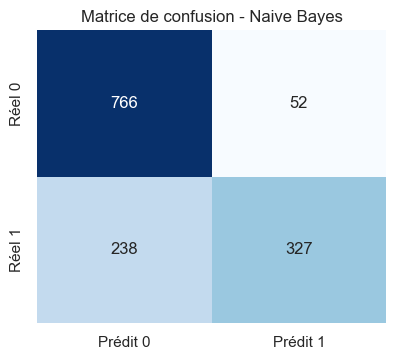

In [20]:
def afficher_resultats(nom, y_true, y_pred):
    # Rapport complet par classe
    print(f'===== {nom} =====')
    print(classification_report(y_true, y_pred, target_names=['Pas catastrophe (0)', 'Catastrophe (1)'], digits=3))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Prédit 0', 'Prédit 1'], yticklabels=['Réel 0', 'Réel 1'])
    plt.title(f'Matrice de confusion - {nom}')
    plt.show()

    # On renvoie les métriques pour la comparaison finale
    return {'Modèle': nom,
            'Accuracy': accuracy_score(y_true, y_pred),
            'Précision': precision_score(y_true, y_pred),
            'Rappel': recall_score(y_true, y_pred),
            'F1-score': f1_score(y_true, y_pred)}

res_nb = afficher_resultats('Naive Bayes', y_test, y_pred_nb)

**Interprétation.** Le modèle classe correctement environ 8 tweets sur 10, bien au-dessus des 57 % qu'on obtiendrait en prédisant toujours la classe majoritaire. Le modèle a donc bien appris à reconnaître les tweets de catastrophe à partir de leur vocabulaire.

La matrice de confusion montre que les erreurs ne sont pas symétriques. La précision sur la classe 1 est plus élevée que le rappel : quand le modèle annonce une catastrophe, il a généralement raison, mais il passe à côté d'une partie des vraies catastrophes. Cela s'explique par le fonctionnement de Naive Bayes, qui prend en compte la probabilité a priori de chaque classe. La classe 0 étant majoritaire, le modèle penche vers elle dans les cas incertains.

Les catastrophes manquées sont en général des tweets sans vocabulaire explicite, ou qui décrivent l'événement de manière indirecte. Les fausses alertes viennent surtout des tweets qui utilisent le vocabulaire de catastrophe au sens figuré.

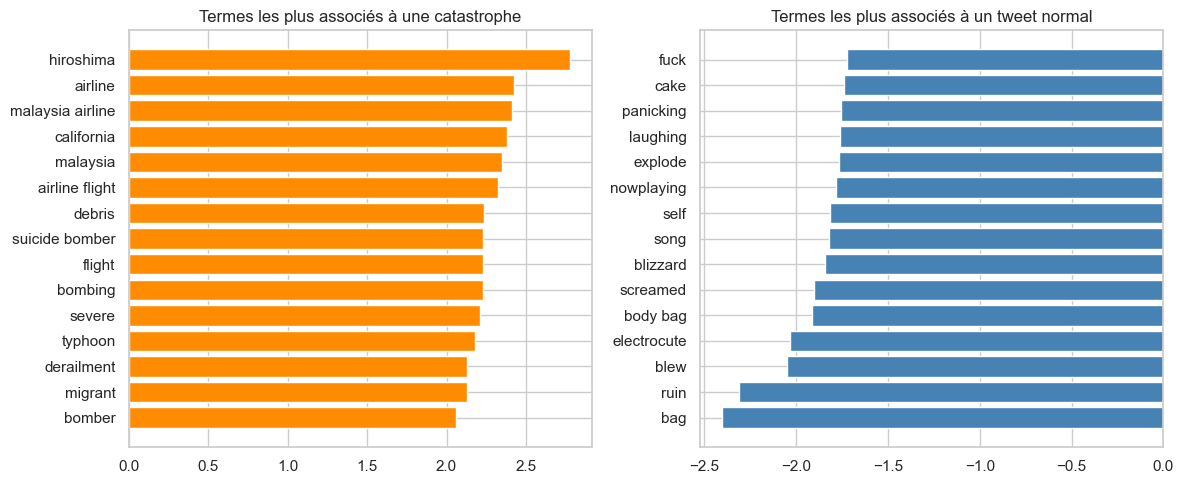

In [21]:
# Mots qui pèsent le plus dans la décision du modèle.
# Pour chaque terme, on compare sa probabilité dans la classe 1 et dans la classe 0 :
# plus la différence de log-probabilité est grande, plus le terme est typique des catastrophes.
termes = tfidf.get_feature_names_out()
diff = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]
ordre = np.argsort(diff)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].barh(termes[ordre[-15:]], diff[ordre[-15:]], color='darkorange')
axes[0].set_title('Termes les plus associés à une catastrophe')
axes[1].barh(termes[ordre[:15]], diff[ordre[:15]], color='steelblue')
axes[1].set_title('Termes les plus associés à un tweet normal')
plt.tight_layout()
plt.show()

Les termes qui poussent le plus vers la classe "catastrophe" désignent des événements précis et souvent des bilans (morts, blessés, évacuations), avec des bigrammes typiques des titres d'actualité. À l'inverse, les termes associés aux tweets normaux relèvent de la conversation et des émotions. Le modèle s'appuie donc sur des indices cohérents avec le sens du texte, et non sur des artefacts du dataset, ce qui renforce la confiance dans ses prédictions.

## 7. Modèle 2 (bonus) : CNN avec embeddings

Pour le bonus, nous comparons Naive Bayes à un modèle de deep learning : un réseau de neurones convolutif à une dimension (CNN 1D). Nous reprenons la démarche du script `deep_learning.py` du TP 2.2.

**Différence avec le modèle 1.** Avec le TF-IDF, l'ordre des mots est perdu (sauf pour les bigrammes). Le CNN reçoit au contraire la séquence de mots dans l'ordre, et apprend lui-même une représentation de chaque mot (embedding).

### 7.1 Vectorisation avec l'algorithme get_top_xwords

La couche d'embedding prend en entrée une suite d'indices de mots. Pour construire ces séquences, on utilise l'algorithme `get_top_xwords` du TP 2.2 :
- `count_top_x_words` compte la fréquence de chaque token et garde les `top_x` mots les plus fréquents ;
- `replace_top_x_words_with_vectors` remplace chaque mot d'un tweet par son indice dans ce vocabulaire (les mots hors vocabulaire sont ignorés) ;
- `filter_to_top_x` enchaîne les deux.

On écrit le module dans `lib/get_top_xwords.py` pour l'importer comme dans le projet d'origine.

In [22]:
os.makedirs('lib', exist_ok=True)
open('lib/__init__.py', 'w').close()   # pour que lib soit reconnu comme un package

In [23]:
%%writefile lib/get_top_xwords.py
from nltk import word_tokenize
from collections import defaultdict


def count_top_x_words(corpus, top_x, skip_top_n):
    count = defaultdict(lambda: 0)
    for c in corpus:
        for w in word_tokenize(c):
            count[w] += 1
    count_tuples = sorted([(w, c) for w, c in count.items()], key=lambda x: x[1], reverse=True)
    return [i[0] for i in count_tuples[skip_top_n: skip_top_n + top_x]]


def replace_top_x_words_with_vectors(corpus, top_x):
    topx_dict = {top_x[i]: i for i in range(len(top_x))}

    return [
        [topx_dict[w] for w in word_tokenize(s) if w in topx_dict]
        for s in corpus
    ], topx_dict


def filter_to_top_x(corpus, n_top, skip_n_top=0):
    top_x = count_top_x_words(corpus, n_top, skip_n_top)
    return replace_top_x_words_with_vectors(corpus, top_x)

Overwriting lib/get_top_xwords.py


Nous avons adapté l'utilisation de ce module sur deux points :

1. Dans `deep_learning.py`, `filter_to_top_x` était appliqué à tout le corpus avant le découpage train/test. Pour éviter la fuite de données, on construit le vocabulaire avec `count_top_x_words` sur le train seulement, puis on convertit le train et le test avec `replace_top_x_words_with_vectors`.
2. Le module donne l'indice 0 au mot le plus fréquent. Or la fonction de padding (étape suivante) complète les tweets courts avec des 0 : le réseau confondrait ce mot avec une case vide. On décale donc tous les indices de 1, et l'indice 0 est réservé au padding.

Le script d'origine ignorait aussi les 10 mots les plus fréquents (`skip_top_n=10`), car les stopwords n'avaient pas été retirés. Dans notre cas, ils l'ont déjà été, donc on ne saute aucun mot.

In [24]:
from lib.get_top_xwords import count_top_x_words, replace_top_x_words_with_vectors

N_MOTS = 5000   # taille du vocabulaire gardé

# Vocabulaire construit sur le train uniquement
top_mots = count_top_x_words(list(X_train), N_MOTS, 0)

# Conversion des tweets en suites d'indices
seq_train, dico_mots = replace_top_x_words_with_vectors(list(X_train), top_mots)
seq_test, _ = replace_top_x_words_with_vectors(list(X_test), top_mots)

# Décalage de +1 : l'indice 0 sert au padding
seq_train = [[i + 1 for i in s] for s in seq_train]
seq_test = [[i + 1 for i in s] for s in seq_test]
taille_vocab = len(top_mots) + 1

print('Taille du vocabulaire :', len(top_mots))
print('Exemple :', X_train.iloc[0])
print('Indices :', seq_train[0])

Taille du vocabulaire : 5000
Exemple : protest rally stone mountain atleast not burning building looting store like individual protest
Indices : [1503, 1715, 1504, 785, 4864, 1, 32, 22, 2494, 1329, 3, 1330, 1503]


### 7.2 Padding

Le réseau attend des entrées de même longueur. `pad_sequences` complète les tweets courts avec des 0 et coupe les tweets trop longs. Le TP 2.2 utilisait une longueur de 150 pour des critiques de vin. Nos tweets nettoyés sont beaucoup plus courts, donc on choisit une longueur qui couvre 99 % des tweets du train.

In [25]:
longueurs = [len(s) for s in seq_train]
MAX_LEN = int(np.percentile(longueurs, 99))
print('Longueur maximale retenue :', MAX_LEN)

X_train_seq = keras.utils.pad_sequences(seq_train, maxlen=MAX_LEN)
X_test_seq = keras.utils.pad_sequences(seq_test, maxlen=MAX_LEN)
print('Forme des données d\'entrée :', X_train_seq.shape)
print('Exemple après padding :', X_train_seq[0])

Longueur maximale retenue : 16
Forme des données d'entrée : (5532, 16)
Exemple après padding : [   0    0    0 1503 1715 1504  785 4864    1   32   22 2494 1329    3
 1330 1503]


### 7.3 Architecture et entraînement du CNN

Le réseau reprend la structure de `deep_learning.py` :
- **Embedding** : chaque indice de mot est transformé en un vecteur de 64 dimensions, appris pendant l'entraînement. Des mots utilisés dans des contextes proches ("fire", "wildfire", "blaze") obtiennent des vecteurs proches. C'est le principe des word embeddings (comme Word2Vec ou GloVe), mais appris directement sur notre tâche.
- **Conv1D** : des filtres glissent sur la séquence et détectent des motifs de 3 mots consécutifs, par exemple "forest fire near". C'est ce qui permet au CNN de prendre en compte l'ordre des mots.
- **GlobalMaxPooling1D** : pour chaque filtre, on garde sa détection la plus forte dans le tweet. Nous l'avons préféré au `Flatten` du script d'origine, car il réduit fortement le nombre de paramètres et donc le sur-apprentissage.
- **Dense** puis **sortie à 1 neurone avec sigmoïde** : on obtient une probabilité entre 0 et 1 que le tweet parle d'une catastrophe. Le script d'origine avait 10 sorties avec softmax car il classait 10 cépages. Notre problème est binaire.
- **Dropout** : pendant l'entraînement, on désactive au hasard 50 % des neurones, ce qui limite le sur-apprentissage sur un petit dataset.

On utilise la fonction de perte `binary_crossentropy`, adaptée à la classification binaire, et l'optimiseur Adam comme dans le TP 2.2. On garde 10 % du train comme jeu de validation, et on arrête l'entraînement quand la perte de validation ne s'améliore plus (`EarlyStopping`), au lieu de fixer le nombre d'époques à 3 comme dans le script d'origine.

In [26]:
cnn = keras.Sequential([
    keras.Input(shape=(MAX_LEN,)),
    layers.Embedding(input_dim=taille_vocab, output_dim=64),
    layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    layers.GlobalMaxPooling1D(),
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid'),
])

cnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 16, 64)         │       320,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 16, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,529 (1.28 MB)

 Trainable params: 334,529 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

La plupart des paramètres se trouvent dans la couche d'embedding (5 001 mots × 64 dimensions, soit environ 320 000 paramètres). C'est beaucoup par rapport au nombre de tweets d'entraînement, d'où l'importance du Dropout et de l'arrêt anticipé.

In [27]:
arret = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

historique = cnn.fit(X_train_seq, y_train,
                     validation_split=0.1,
                     epochs=20,
                     batch_size=64,
                     callbacks=[arret],
                     verbose=2)

Epoch 1/20
78/78 - 4s - 50ms/step - accuracy: 0.5822 - loss: 0.6784 - val_accuracy: 0.5812 - val_loss: 0.6615
Epoch 2/20
78/78 - 1s - 11ms/step - accuracy: 0.7121 - loss: 0.5933 - val_accuracy: 0.7942 - val_loss: 0.4875
Epoch 3/20
78/78 - 1s - 8ms/step - accuracy: 0.8397 - loss: 0.4017 - val_accuracy: 0.7996 - val_loss: 0.4666
Epoch 4/20
78/78 - 1s - 8ms/step - accuracy: 0.9092 - loss: 0.2714 - val_accuracy: 0.7816 - val_loss: 0.5341
Epoch 5/20
78/78 - 1s - 7ms/step - accuracy: 0.9385 - loss: 0.1897 - val_accuracy: 0.7780 - val_loss: 0.6203
Epoch 6/20
78/78 - 1s - 9ms/step - accuracy: 0.9548 - loss: 0.1431 - val_accuracy: 0.7690 - val_loss: 0.7476


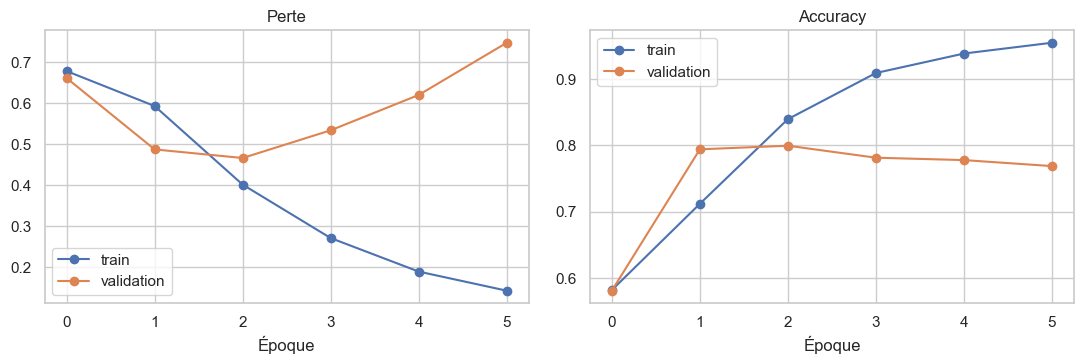

In [28]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(historique.history['loss'], 'o-', label='train')
axes[0].plot(historique.history['val_loss'], 'o-', label='validation')
axes[0].set_title('Perte')
axes[1].plot(historique.history['accuracy'], 'o-', label='train')
axes[1].plot(historique.history['val_accuracy'], 'o-', label='validation')
axes[1].set_title('Accuracy')
for ax in axes:
    ax.set_xlabel('Époque')
    ax.legend()
plt.tight_layout()
plt.show()

**Interprétation des courbes.** La perte sur le train baisse à chaque époque, alors que la perte de validation atteint un minimum après quelques époques puis remonte. C'est le signe du sur-apprentissage : au-delà de ce point, le réseau mémorise les tweets d'entraînement au lieu d'apprendre des règles générales. L'`EarlyStopping` arrête l'entraînement et restaure les poids de la meilleure époque. On voit aussi que l'écart entre accuracy train et validation se creuse vite, ce qui est attendu avec autant de paramètres pour quelques milliers d'exemples.

===== CNN =====
                     precision    recall  f1-score   support

Pas catastrophe (0)      0.787     0.874     0.829       818
    Catastrophe (1)      0.783     0.658     0.715       565

           accuracy                          0.786      1383
          macro avg      0.785     0.766     0.772      1383
       weighted avg      0.786     0.786     0.782      1383



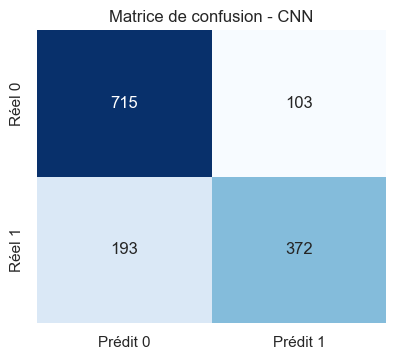

In [29]:
# Prédiction : le réseau renvoie une probabilité, on classe en 1 si elle dépasse 0.5
proba_cnn = cnn.predict(X_test_seq, verbose=0).ravel()
y_pred_cnn = (proba_cnn >= 0.5).astype(int)

res_cnn = afficher_resultats('CNN', y_test, y_pred_cnn)

**Interprétation.** Le CNN obtient des résultats du même ordre que Naive Bayes, nettement meilleurs que la classe majoritaire. Comme Naive Bayes, il se trompe surtout sur les tweets ambigus : vocabulaire de catastrophe au sens figuré, ou catastrophe décrite sans mot explicite. La comparaison détaillée des deux modèles est faite dans la partie suivante.

## 8. Comparaison des deux modèles (bonus)

In [30]:
comparaison = pd.DataFrame([res_nb, res_cnn]).set_index('Modèle').round(3)
comparaison

,Accuracy,Précision,Rappel,F1-score
Modèle,,,,
Naive Bayes,0.790,0.863,0.579,0.693
CNN,0.786,0.783,0.658,0.715


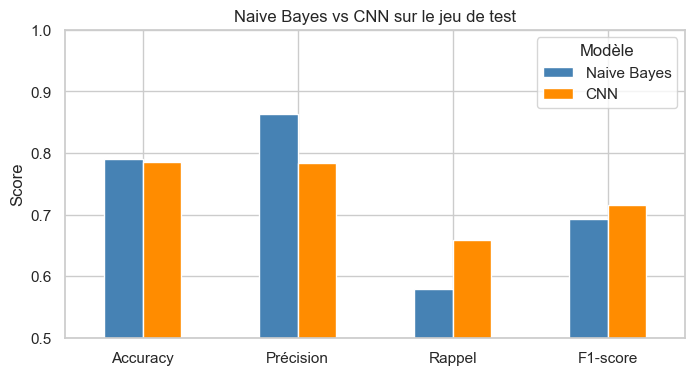

In [31]:
comparaison.T.plot(kind='bar', figsize=(8, 4), rot=0, color=['steelblue', 'darkorange'])
plt.ylim(0.5, 1)
plt.ylabel('Score')
plt.title('Naive Bayes vs CNN sur le jeu de test')
plt.show()

**Quel modèle donne les meilleurs résultats, et pourquoi ?**

Les deux modèles ont une accuracy presque identique (0,790 pour Naive Bayes contre 0,786 pour le CNN), mais ils ne font pas les mêmes erreurs :

- **Naive Bayes** a la meilleure précision (0,863) mais un rappel faible (0,579). Quand il annonce une catastrophe, il se trompe rarement, mais il laisse passer plus de 4 vraies catastrophes sur 10.
- **Le CNN** a une précision plus faible (0,783) mais un rappel nettement meilleur (0,658). Il déclenche un peu plus de fausses alertes, mais il détecte environ 8 points de catastrophes en plus.

Le F1-score, qui combine précision et rappel, est notre métrique principale. Il place le **CNN en tête (0,715 contre 0,693)**. Pour notre cas d'usage, c'est aussi le modèle le plus adapté : pour un service d'alerte, rater une vraie catastrophe coûte plus cher qu'une fausse alerte, qu'un opérateur peut facilement écarter.

**Pourquoi le CNN a-t-il un meilleur rappel ?**

1. **Naive Bayes est prudent par construction.** Sa décision intègre la probabilité a priori de chaque classe. La classe 0 étant majoritaire (57 %), le modèle penche vers elle dès qu'un tweet n'a pas de vocabulaire de catastrophe très marqué. D'où beaucoup de catastrophes manquées.
2. **Les embeddings du CNN généralisent mieux.** Pour Naive Bayes, chaque mot est une variable indépendante : un mot rare ou absent du vocabulaire TF-IDF (filtré par `min_df=2`) n'apporte rien. Le CNN, lui, apprend des vecteurs proches pour des mots utilisés dans des contextes similaires. Il peut donc reconnaître une catastrophe décrite avec un vocabulaire moins fréquent.
3. **Le CNN tient compte de l'ordre des mots.** Ses filtres détectent des suites de 3 mots, ce qui aide sur des formulations indirectes que le sac de mots ne capte pas.

**À nuancer.** L'écart de F1 (0,022) reste modeste et a été mesuré sur un seul découpage train/test. Il pourrait varier un peu avec un autre découpage. Naive Bayes garde aussi de vrais avantages : il s'entraîne en une fraction de seconde, ne sur-apprend pas, et reste interprétable (on sait quels mots ont déclenché l'alerte). Le CNN demande plus de réglages et sur-apprend vite, comme le montrent les courbes d'apprentissage.

Les deux modèles partagent la même limite : le langage figuré et l'ironie, qui demandent de comprendre le contexte global de la phrase.

## 9. Test sur de nouveaux tweets

On vérifie le comportement des deux modèles sur des tweets inventés, dont deux utilisent du vocabulaire de catastrophe au sens figuré. Les nouveaux tweets passent par exactement le même nettoyage que les données d'entraînement.

In [32]:
nouveaux_tweets = [
    'Forest fire near the city, residents are asked to evacuate',
    'Earthquake of magnitude 6.2 hits the coast, several buildings collapsed',
    'This new album is fire, the last track is the bomb!',
    'I was dying of laughter at the party last night',
]

nettoyes = [nettoyer_tweet(t) for t in nouveaux_tweets]

# Naive Bayes : TF-IDF déjà entraîné
pred_nb = nb_model.predict(tfidf.transform(nettoyes))

# CNN : même conversion en indices (+1) et même padding que pour le train
seq, _ = replace_top_x_words_with_vectors(nettoyes, top_mots)
seq = keras.utils.pad_sequences([[i + 1 for i in s] for s in seq], maxlen=MAX_LEN)
pred_cnn = (cnn.predict(seq, verbose=0).ravel() >= 0.5).astype(int)

pd.DataFrame({'tweet': nouveaux_tweets, 'Naive Bayes': pred_nb, 'CNN': pred_cnn})

,tweet,Naive Bayes,CNN
0,"Forest fire near the city, residents are asked to evacuate",1,1
1,"Earthquake of magnitude 6.2 hits the coast, several buildings collapsed",1,1
2,"This new album is fire, the last track is the bomb!",0,0
3,I was dying of laughter at the party last night,0,0


Les deux premiers tweets décrivent de vraies catastrophes et devraient être classés 1. Les deux derniers utilisent "fire", "bomb" et "dying" au sens figuré et devraient être classés 0. Si un modèle se trompe sur ces deux derniers, cela illustre la limite évoquée plus haut : sans compréhension du contexte, un mot fortement associé aux catastrophes peut suffire à déclencher une fausse alerte.

## 10. Conclusion

Dans ce TP, nous avons construit une chaîne complète de NLP pour détecter les tweets qui annoncent une vraie catastrophe :
- **exploration** du dataset : classes légèrement déséquilibrées, doublons, textes courts, vocabulaire commun aux deux classes ;
- **nettoyage** adapté aux tweets : suppression des doublons, minuscules, suppression du bruit en gardant les négations, tokenisation, stopwords, lemmatisation ;
- **deux vectorisations** : TF-IDF pour Naive Bayes, et séquences d'indices construites avec l'algorithme get_top_xwords pour le CNN ;
- **deux modèles** évalués avec l'accuracy, la précision, le rappel, le F1-score et la matrice de confusion.

Les deux modèles détectent correctement la grande majorité des tweets. Sur ce dataset de petite taille et de textes courts, le modèle simple (Naive Bayes) rivalise avec le modèle de deep learning, tout en étant plus rapide et plus facile à interpréter. La principale limite reste le langage figuré. Pour aller plus loin, on pourrait utiliser des modèles pré-entraînés sur de grandes quantités de texte, comme BERT, qui prennent en compte le contexte de la phrase.